[CircuitInstruction(operation=Instruction(name='cu3', num_qubits=2, num_clbits=0, params=[2.9963528206870698, 1.9971213306587734, 5.9737866788536165]), qubits=(Qubit(QuantumRegister(2, 'q'), 0), Qubit(QuantumRegister(2, 'q'), 1)), clbits=()), CircuitInstruction(operation=Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(2, 'q'), 1), Qubit(QuantumRegister(2, 'q'), 0)), clbits=()), CircuitInstruction(operation=Instruction(name='ch', num_qubits=2, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(2, 'q'), 1), Qubit(QuantumRegister(2, 'q'), 0)), clbits=()), CircuitInstruction(operation=Instruction(name='s', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(2, 'q'), 0),), clbits=()), CircuitInstruction(operation=Instruction(name='u', num_qubits=1, num_clbits=0, params=[3.7979872003994894, 3.0871255623150224, 0.2891177641263976]), qubits=(Qubit(QuantumRegister(2, 'q'), 1),), clbits=()), CircuitInstruction(operation=Instruct

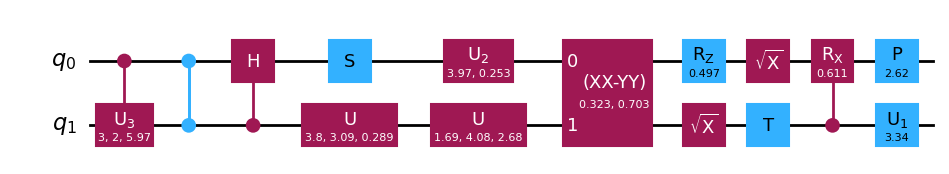

In [2]:
from qiskit import QuantumCircuit
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Statevector

qc = random_circuit(2, max_operands =2, depth = 10)
print(qc.data)
qc.draw('mpl')



In [152]:
# gate latex names and parameters
import json
import numpy as np
import pandas as pd

with open('gates.json', 'r') as file:
    quantum_gates = json.load(file)

def categorize_gate(gate_name):
    gate_name = gate_name.lower()
    for category, gates in quantum_gates.items():
        for gate in gates: 
            if gate_name == gate['name']: 
                return category, gate['latex']
names = []
params = []
idxs = []
categories = []
for instruction in qc.data: 
    category, latex = categorize_gate(instruction.operation.name)

    categories.append(category)
    names.append(latex)
    params.append([i for i in instruction.operation.params if isinstance(i, np.float64)])
    idxs.append([qc.find_bit(qubit).index for qubit in instruction.qubits])

circuit_data = pd.DataFrame({
    'category': categories,
    'names': names, 
    'params': params, 
    'idxs': idxs
})

In [153]:
display(circuit_data)

,category,names,params,idxs
0,single_qubit_gates,S,[],[0]
1,single_qubit_gates,I,[],[1]
2,cx_like_gates,CY,[],"[1, 0]"
3,multi_qubit_gates,XX + YY,"[5.374748011030326, 5.253020568829901]","[0, 1]"
4,general_controlled_gates,CR_x,[5.008800860371561],"[0, 1]"
5,cx_like_gates,CY,[],"[1, 0]"
6,single_qubit_gates,U,"[1.709044843052112, 2.9353199689051697, 4.5461...",[0]
7,single_qubit_gates,T,[],[1]
8,cphase_gates,CU,"[1.2361259977972268, 2.58910077411368, 3.59693...","[1, 0]"
9,single_qubit_gates,I,[],[1]


In [199]:
for i, j in circuit_data.iterrows(): 
    print(j.iloc[0])


single_qubit_gates
single_qubit_gates
cx_like_gates
multi_qubit_gates
general_controlled_gates
cx_like_gates
single_qubit_gates
single_qubit_gates
cphase_gates
single_qubit_gates
single_qubit_gates
multi_qubit_gates
cphase_gates


[CircuitInstruction(operation=Instruction(name='s', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(1, 'q'), 0),), clbits=()), CircuitInstruction(operation=Instruction(name='sdg', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(1, 'q'), 0),), clbits=()), CircuitInstruction(operation=Instruction(name='u1', num_qubits=1, num_clbits=0, params=[0.9057815605287021]), qubits=(Qubit(QuantumRegister(1, 'q'), 0),), clbits=()), CircuitInstruction(operation=Instruction(name='z', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(1, 'q'), 0),), clbits=()), CircuitInstruction(operation=Instruction(name='u2', num_qubits=1, num_clbits=0, params=[1.9592947975887585, 2.659838524324996]), qubits=(Qubit(QuantumRegister(1, 'q'), 0),), clbits=())]


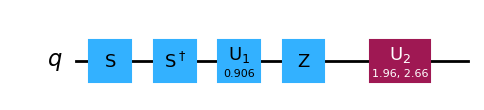

In [33]:
qc1 = random_circuit(1, depth = 5, seed = 1)
print(qc1.data)
qc1.draw('mpl')

[CircuitInstruction(operation=Instruction(name='u', num_qubits=1, num_clbits=0, params=[3.212765766999291, 6.133920107929199, 0.5079077176316655]), qubits=(Qubit(QuantumRegister(1, 'q'), 0),), clbits=()), CircuitInstruction(operation=Instruction(name='y', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(1, 'q'), 0),), clbits=()), CircuitInstruction(operation=Instruction(name='s', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(1, 'q'), 0),), clbits=()), CircuitInstruction(operation=Instruction(name='t', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(1, 'q'), 0),), clbits=()), CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(1, 'q'), 0),), clbits=())]


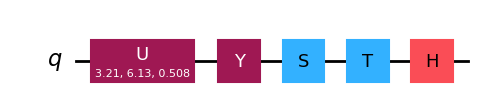

In [22]:
qc2 = random_circuit(1, depth = 2, seed = 4)
print(qc2.data)
qc2.draw('mpl')

In [15]:
zero = Statevector.from_label('0')
q1out = zero.evolve(qc1)
q2out = zero.evolve(qc2)

In [21]:
display(q1out.draw('latex'))
display(q2out.draw('latex'))
display(q1out.tensor(q2out).draw('latex'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [32]:
import numpy as np

qc = QuantumCircuit(2)

qc.u(3.212765766999291, 6.133920107929199, 0.5079077176316655, 0)
qc.y(0)
qc.s(0)
qc.t(0)
qc.h(0) 

qc.s(1) 
qc.sdg(1)
qc.p(0.9057815605287021, 1)
qc.z(1)
qc.u(np.pi/2, 1.9592947975887585, 2.659838524324996, 1)

zero.tensor(zero).evolve(qc).draw('latex')

<IPython.core.display.Latex object>

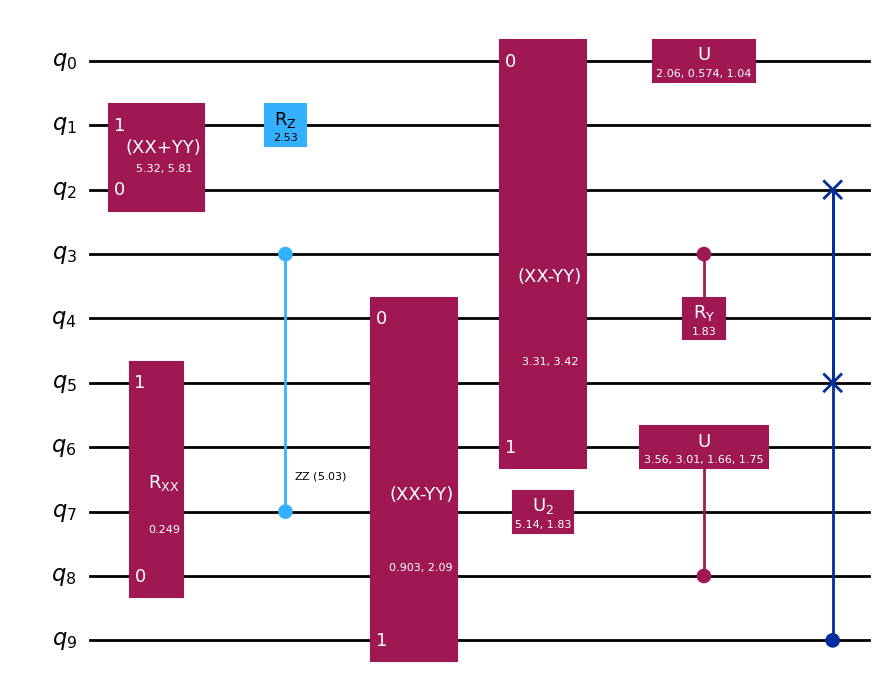

In [36]:
qc = random_circuit(10, depth = 2)
qc.draw('mpl')

In [40]:
qubits = []
for i in qc.data: 
    qubits.append([qc.find_bit(qubit).index for qubit in i.qubits])

qubits

[[8, 5],
 [2, 1],
 [7, 3],
 [4, 9],
 [0, 6],
 [3, 4],
 [9, 5, 2],
 [1],
 [8, 6],
 [0],
 [7]]

In [41]:
from circuit import BuildCircuit

In [42]:
class_ = BuildCircuit() 
class_.decompose(qc)

,category,names,params,idxs
0,multi_qubit_gates,R_{XX},[0.24909483294055035],"[8, 5]"
1,multi_qubit_gates,XX + YY,"[5.315675268609387, 5.808987598941054]","[2, 1]"
2,multi_qubit_gates,R_{ZZ},[5.0297969367795154],"[7, 3]"
3,multi_qubit_gates,XX - YY,"[0.9026955368224142, 2.0942781044050234]","[4, 9]"
4,multi_qubit_gates,XX - YY,"[3.3117342756687145, 3.423323270890607]","[0, 6]"
5,general_controlled_gates,R_y,[1.8299854408635288],"[3, 4]"
6,general_controlled_gates,Cswap,[],"[9, 5, 2]"
7,single_qubit_gates,R_z,[2.5315622189021223],[1]
8,general_controlled_gates,U,"[3.56079910600966, 3.0069412289145183, 1.66035...","[8, 6]"
9,single_qubit_gates,U,"[2.059013599246462, 0.5740038011952188, 1.0394...",[0]


In [47]:
np.array(range(qc.num_qubits-1, -qc.num_qubits, -2))

array([ 9,  7,  5,  3,  1, -1, -3, -5, -7, -9])

In [81]:
x_init = np.zeros((10))
x_init[0] = 5
x_init[3] = 10.25

x_init[[0]].tolist()[0]



5.0

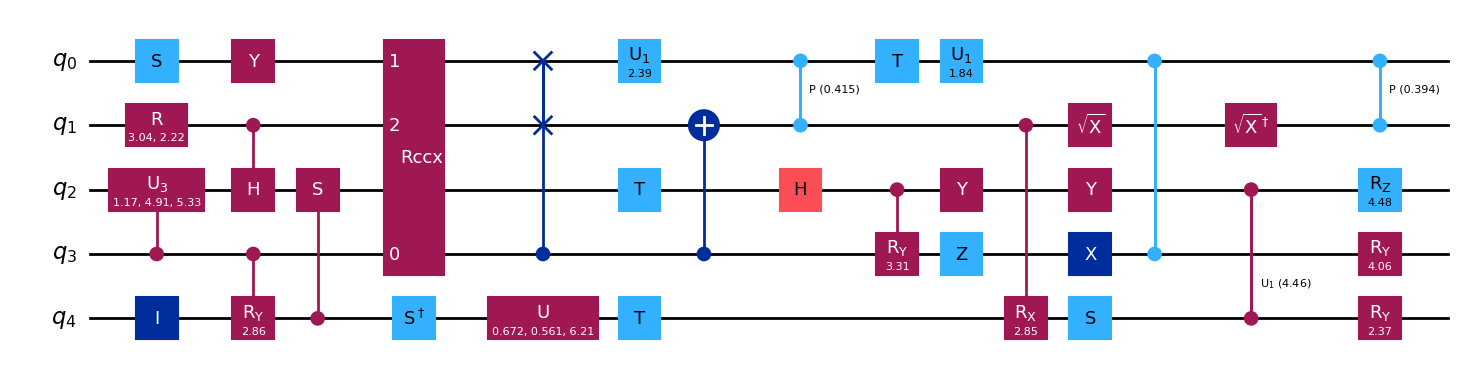

In [83]:
qc = random_circuit(5, depth = 10)
qc.draw('mpl')

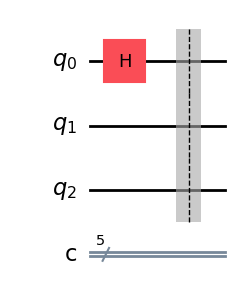

In [15]:
qc = QuantumCircuit(3, 5)
qc.h(0)
qc.barrier()


qc.draw('mpl')

In [20]:
for i in qc.data:
    print(i.qubits)

(Qubit(QuantumRegister(3, 'q'), 0),)
(Qubit(QuantumRegister(3, 'q'), 0), Qubit(QuantumRegister(3, 'q'), 1), Qubit(QuantumRegister(3, 'q'), 2))
